# SKATER Geographic Clustering — Visual Results

Run this notebook after `python -m src.train` has completed.
It shows the Lyon gNodeB map for K = 5, 10, 20 and compares cluster sizes.

In [12]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

REPO     = Path('..')
GRAPHS   = REPO / 'data/graphs'
DATA     = REPO / 'data/cluster_first'
SWEEP_K  = [5, 10, 20]

bs_locs = pd.read_parquet(GRAPHS / 'bs_locations.parquet')
bs_locs['site_id'] = bs_locs['site_id'].astype(str)
print(f'Loaded {len(bs_locs)} BS locations')

Loaded 965 BS locations


## 1 — Lyon Map: K = 5 / 10 / 20 side by side

C:\Users\Shima\AppData\Local\Temp\ipykernel_10892\810493424.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', K)
C:\Users\Shima\AppData\Local\Temp\ipykernel_10892\810493424.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', K)
C:\Users\Shima\AppData\Local\Temp\ipykernel_10892\810493424.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', K)


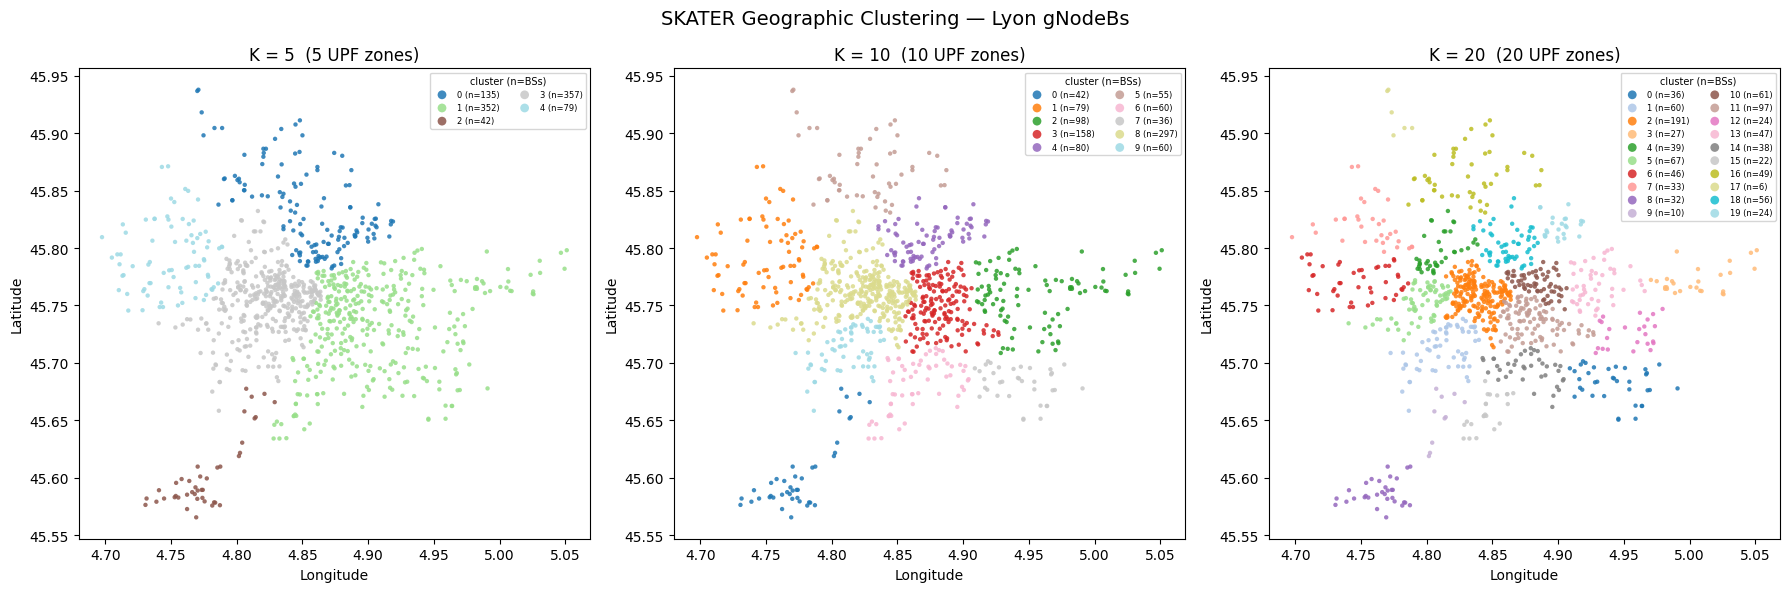

Saved -> figures/cluster_first/skater_map_comparison.png


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, K in zip(axes, SWEEP_K):
    asgn_path = DATA / f'K{K}' / 'cluster_assignments.parquet'
    if not asgn_path.exists():
        ax.set_title(f'K={K} — not trained yet')
        ax.axis('off')
        continue

    asgn = pd.read_parquet(asgn_path)
    asgn['site_id'] = asgn['site_id'].astype(str)
    df = asgn.merge(bs_locs, on='site_id', how='left')

    cmap = plt.cm.get_cmap('tab20', K)
    for k in range(K):
        sub = df[df['cluster_id'] == k]
        ax.scatter(sub['lon'], sub['lat'], s=10, color=cmap(k),
                   alpha=0.85, edgecolors='none', label=f'{k} (n={len(sub)})')

    ax.set_title(f'K = {K}  ({K} UPF zones)', fontsize=12)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.legend(fontsize=6, ncol=2, loc='upper right', markerscale=2,
               title='cluster (n=BSs)', title_fontsize=7)

fig.suptitle('SKATER Geographic Clustering — Lyon gNodeBs', fontsize=14)
plt.tight_layout()
plt.savefig(REPO / 'figures/cluster_first/skater_map_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> figures/cluster_first/skater_map_comparison.png')

## 1b — Coverage Areas (real Voronoi polygons coloured by cluster)

Each polygon is the actual Voronoi cell of one BS — its geographic serving area.
Cells are coloured by the SKATER cluster they belong to, giving a true picture
of each UPF service zone as a contiguous geographic region.

In [14]:
import sys, math, json
from pathlib import Path

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / 'src').exists():
    ROOT = ROOT.parent

sys.path.insert(0, str(ROOT / 'src'))

import yaml
import numpy as np
from shapely.geometry import shape
from shapely.ops import unary_union
from matplotlib.collections import PatchCollection
from matplotlib.patches import Polygon as MplPolygon
from aggregate import load_base_stations, build_voronoi

with open(ROOT / 'params.yaml') as f:
    PARAMS = yaml.safe_load(f)
# Resolve relative paths in PARAMS against ROOT so notebook CWD doesn't matter
PARAMS['aggregation']['bs_csv'] = str(ROOT / PARAMS['aggregation']['bs_csv'])

# City boundary — needed to get the same 965-BS set the pipeline used
geojson_path = ROOT / PARAMS['aggregation']['geojson_path']
with open(geojson_path, encoding='utf-8') as f:
    _gj = json.load(f)
city_boundary = unary_union([shape(feat['geometry']) for feat in _gj['features']])

# Build Voronoi polygons (identical call to 01_analytics.ipynb)
print('Building Voronoi polygons (takes ~10 s) ...')
bs_all  = load_base_stations(PARAMS, city_boundary=city_boundary)
vresult = build_voronoi(bs_all, PARAMS, city_boundary=city_boundary)
lat_ref = vresult.lat_ref
R       = 6_371_000.0

def xy_to_lonlat(x, y):
    lon = np.degrees(x / (R * math.cos(math.radians(lat_ref))))
    lat = np.degrees(y / R)
    return lon, lat

print(f'Voronoi polygons ready — {len(vresult.polygons)} cells')

Building Voronoi polygons (takes ~10 s) ...
[aggregate] Removed 15 co-located BS duplicates (983 -> 968 unique positions)
[aggregate] Loaded 968 base stations
[aggregate] Built 968 Voronoi coverage polygons (clipped to city footprint, 0 empty)
Voronoi polygons ready — 968 cells


C:\Users\Shima\AppData\Local\Temp\ipykernel_10892\662850100.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', K_FOCUS)


Rendering 979 Voronoi polygons for K=10


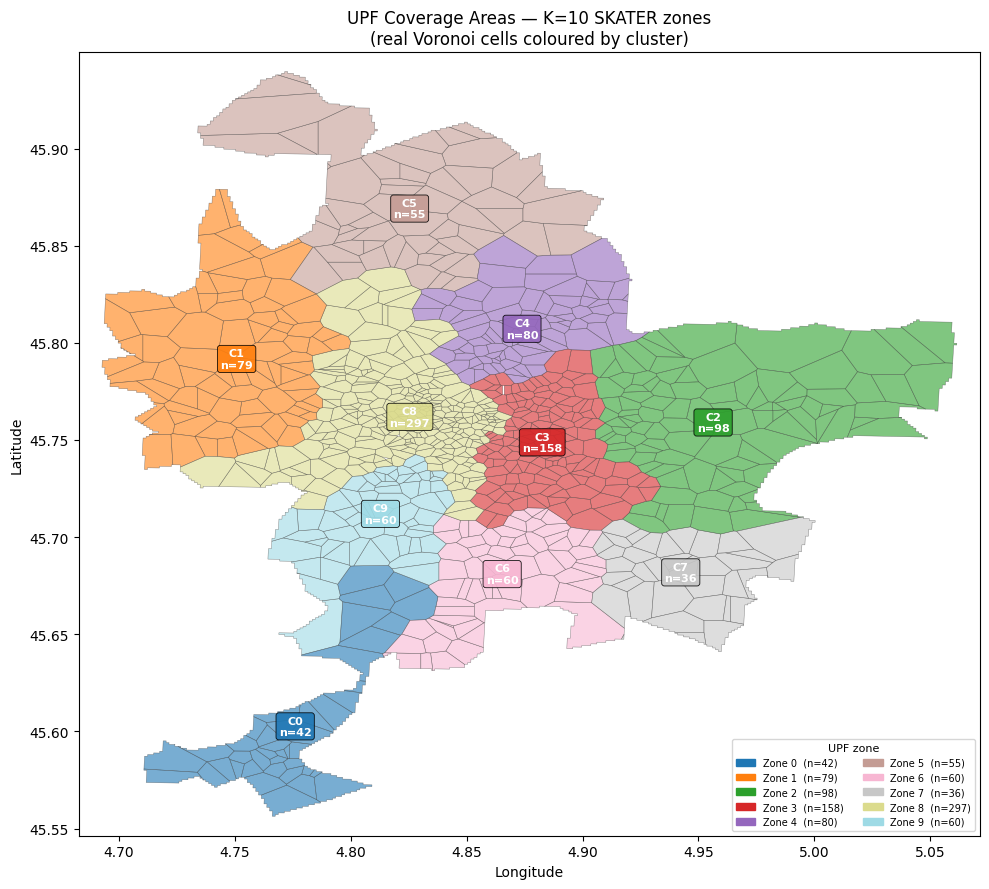

Saved -> ..\figures\cluster_first\skater_voronoi_K10.png


In [15]:
K_FOCUS = 10
asgn_path = DATA / f'K{K_FOCUS}' / 'cluster_assignments.parquet'

if not asgn_path.exists():
    print(f'K={K_FOCUS} not trained yet')
else:
    asgn = pd.read_parquet(asgn_path)
    asgn['site_id'] = asgn['site_id'].astype(str)
    site_to_cluster = dict(zip(asgn['site_id'], asgn['cluster_id']))

    cmap = plt.cm.get_cmap('tab20', K_FOCUS)

    # Build one MplPolygon patch per Voronoi cell, coloured by cluster
    poly_patches  = []
    poly_clusters = []

    for i, poly in enumerate(vresult.polygons):
        if poly is None or poly.is_empty:
            continue
        sid = str(bs_all.iloc[i]['site_id'])
        if sid not in site_to_cluster:
            continue                          # BS outside node_index — skip
        cluster_id = site_to_cluster[sid]

        geoms = list(poly.geoms) if poly.geom_type == 'MultiPolygon' else [poly]
        for part in geoms:
            xy = np.array(part.exterior.coords)
            lon, lat = xy_to_lonlat(xy[:, 0], xy[:, 1])
            poly_patches.append(MplPolygon(np.column_stack([lon, lat]), closed=True))
            poly_clusters.append(cluster_id)

    print(f'Rendering {len(poly_patches)} Voronoi polygons for K={K_FOCUS}')

    fig, ax = plt.subplots(figsize=(10, 9))

    pc = PatchCollection(poly_patches, cmap=cmap, alpha=0.60,
                         linewidths=0.35, edgecolors='#444444', zorder=3)
    pc.set_array(np.array(poly_clusters, dtype=float))
    pc.set_clim(-0.5, K_FOCUS - 0.5)
    ax.add_collection(pc)

    # Cluster centroid labels
    asgn_loc  = asgn.merge(bs_locs, on='site_id', how='left').dropna(subset=['lat','lon'])
    centroids = asgn_loc.groupby('cluster_id')[['lon','lat']].mean()
    sizes_k   = asgn_loc.groupby('cluster_id').size()
    for k, row in centroids.iterrows():
        ax.text(row['lon'], row['lat'], f'C{k}\nn={sizes_k[k]}',
                ha='center', va='center', fontsize=8, fontweight='bold',
                color='white',
                bbox=dict(boxstyle='round,pad=0.25', fc=cmap(k / K_FOCUS),
                          alpha=0.9, ec='black', lw=0.6))

    _b = city_boundary.bounds
    ax.set_xlim(_b[0] - 0.01, _b[2] + 0.01)
    ax.set_ylim(_b[1] - 0.01, _b[3] + 0.01)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.set_title(f'UPF Coverage Areas — K={K_FOCUS} SKATER zones\n'
                 f'(real Voronoi cells coloured by cluster)', fontsize=12)

    handles = [mpatches.Patch(color=cmap(k / K_FOCUS),
                               label=f'Zone {k}  (n={sizes_k.get(k,"?")})')
               for k in range(K_FOCUS)]
    ax.legend(handles=handles, fontsize=7, ncol=2,
               loc='lower right', title='UPF zone', title_fontsize=8)

    plt.tight_layout()
    out = REPO / f'figures/cluster_first/skater_voronoi_K{K_FOCUS}.png'
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved -> {out}')

## 2 — Cluster Size Distribution per K

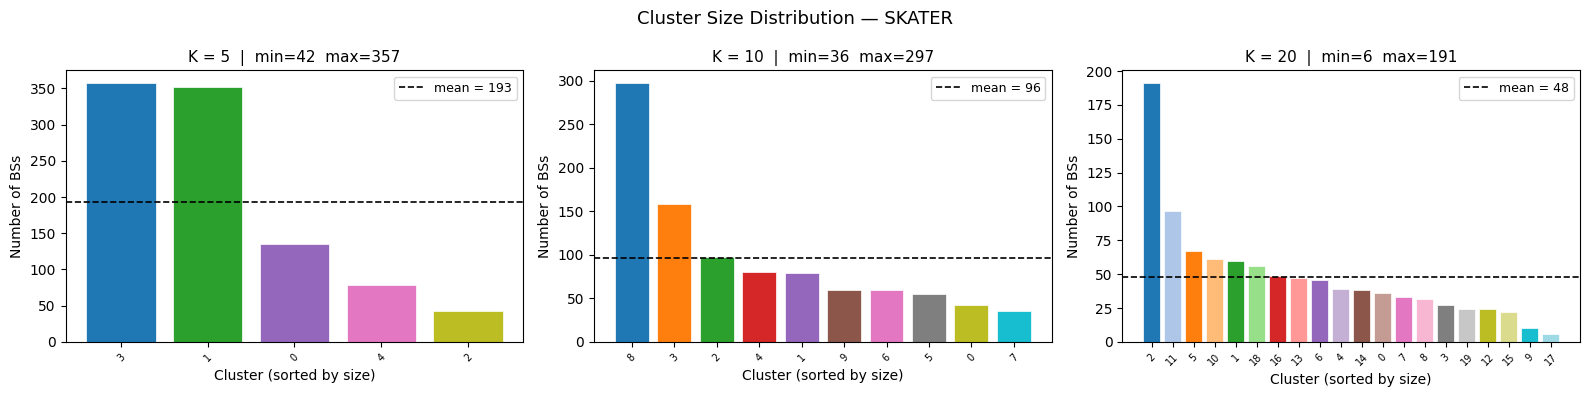

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, K in zip(axes, SWEEP_K):
    asgn_path = DATA / f'K{K}' / 'cluster_assignments.parquet'
    if not asgn_path.exists():
        ax.set_title(f'K={K} — not trained yet'); ax.axis('off'); continue

    asgn   = pd.read_parquet(asgn_path)
    sizes  = asgn.groupby('cluster_id').size().sort_values(ascending=False)
    colors = [plt.cm.tab20(i / K) for i in range(K)]

    ax.bar(range(len(sizes)), sizes.values, color=colors, edgecolor='white', linewidth=0.5)
    ax.axhline(sizes.mean(), color='black', linewidth=1.2, linestyle='--',
                label=f'mean = {sizes.mean():.0f}')
    ax.set_title(f'K = {K}  |  min={sizes.min()}  max={sizes.max()}', fontsize=11)
    ax.set_xlabel('Cluster (sorted by size)')
    ax.set_ylabel('Number of BSs')
    ax.legend(fontsize=9)
    ax.set_xticks(range(len(sizes)))
    ax.set_xticklabels(sizes.index, fontsize=7, rotation=45)

fig.suptitle('Cluster Size Distribution — SKATER', fontsize=13)
plt.tight_layout()
plt.savefig(REPO / 'figures/cluster_first/skater_size_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()

## 3 — Cluster Traffic Signals (K=10)

C:\Users\Shima\AppData\Local\Temp\ipykernel_10892\3918830553.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap   = plt.cm.get_cmap('tab20', K_FOCUS)


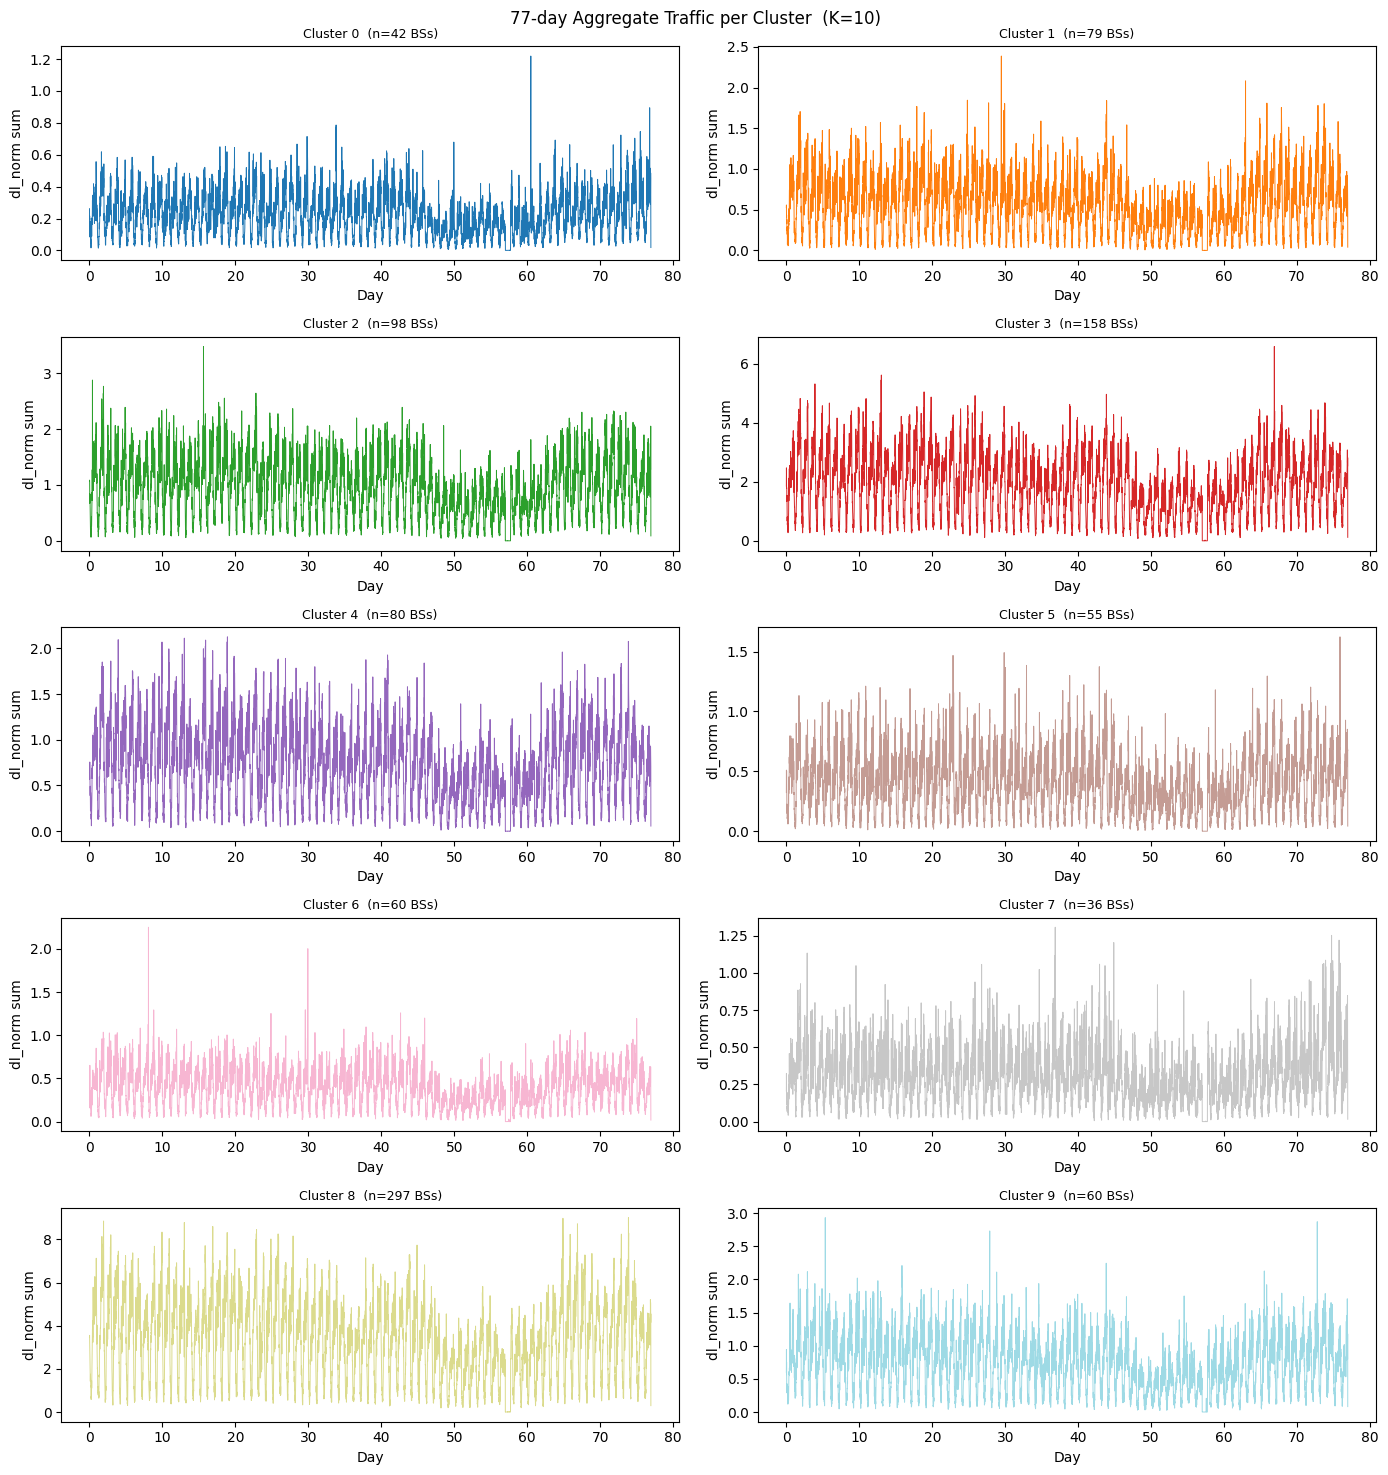

In [17]:
K_FOCUS = 10
series_path = DATA / f'K{K_FOCUS}' / 'cluster_series.npy'

if not series_path.exists():
    print(f'cluster_series not found for K={K_FOCUS} — run training first')
else:
    cs = np.load(series_path)          # (K, T_total)
    T  = cs.shape[1]
    t  = np.arange(T) / 96             # days from start

    cmap   = plt.cm.get_cmap('tab20', K_FOCUS)
    n_cols = 2
    n_rows = (K_FOCUS + 1) // 2
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 3 * n_rows), squeeze=False)

    asgn  = pd.read_parquet(DATA / f'K{K_FOCUS}' / 'cluster_assignments.parquet')
    sizes = asgn.groupby('cluster_id').size()

    for k in range(K_FOCUS):
        ax = axes[k // n_cols][k % n_cols]
        ax.plot(t, cs[k], color=cmap(k), linewidth=0.7)
        ax.set_title(f'Cluster {k}  (n={sizes.get(k, "?")} BSs)', fontsize=9)
        ax.set_xlabel('Day')
        ax.set_ylabel('dl_norm sum')

    for k in range(K_FOCUS, n_rows * n_cols):
        axes[k // n_cols][k % n_cols].set_visible(False)

    fig.suptitle(f'77-day Aggregate Traffic per Cluster  (K={K_FOCUS})', fontsize=12)
    plt.tight_layout()
    plt.savefig(REPO / f'figures/cluster_first/skater_signals_K{K_FOCUS}.png',
                dpi=150, bbox_inches='tight')
    plt.show()

## 4 — Summary Table

In [18]:
rows = []
for K in SWEEP_K:
    p = DATA / f'K{K}' / 'cluster_assignments.parquet'
    if not p.exists():
        continue
    sizes = pd.read_parquet(p).groupby('cluster_id').size()
    rows.append({
        'K':        K,
        'min_BSs':  int(sizes.min()),
        'max_BSs':  int(sizes.max()),
        'mean_BSs': round(sizes.mean(), 1),
        'std_BSs':  round(sizes.std(), 1),
        'singletons': int((sizes == 1).sum()),
    })

summary = pd.DataFrame(rows).set_index('K')
print(summary.to_string())
display(summary)

    min_BSs  max_BSs  mean_BSs  std_BSs  singletons
K                                                  
5        42      357     193.0    151.1           0
10       36      297      96.5     78.6           0
20        6      191      48.2     39.7           0


,min_BSs,max_BSs,mean_BSs,std_BSs,singletons
K,,,,,
5,42,357,193.0,151.1,0
10,36,297,96.5,78.6,0
20,6,191,48.2,39.7,0
